<a href="https://colab.research.google.com/github/bobsi1/Algorithms_BDML_1year/blob/main/A1_Rubtcova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rubtcova Vera  
Algorithms Task 1

Goal:  
Experimental study of the time complexity of different algorithms

Task:  
For each n from 1 to 2000, measure the average computer execution time (using timestamps) of programs implementing the algorithms and functions below for five runs. Plot the data obtained showing the average execution time as a function of n. Conduct the theoretical analysis of the time complexity of the algorithms in question and compare the empirical and theoretical time complexities.  

Problems:  
1. Generate an n-dimensional random vector **v** = [𝒗₁, 𝒗₂, ..., 𝒗ₙ] with non-negative
elements.  For 𝒗, implement the following calculations and algorithms:
  - 𝑓(𝒗) = 𝑐𝑜𝑛𝑠𝑡 (constant function);   
  - 𝑓(𝒗) = Σ𝒗ᵢ (the sum of elements);   
  - 𝑓(𝒗) = ∏𝒗ᵢ (the product of elements);   
  - supposing that the elements of 𝒗 are the coefficients of polynomial 𝑃 of degree 𝑛 −1,  calculate the value 𝑃(1.5) by a direct calculation of P(x) = Σ 𝒗ᵢxⁱ (i.e. evaluating each term one by one) and by Horner’s method by representing the polynomial as P(x) = 𝒗₁ + x(𝒗₂ + x(𝒗₃ + ⋯));  
  - Bubble Sort of the elements of 𝒗;   
  - Quick Sort of the elements of 𝒗;   
  - Timsort of the elements of 𝒗.   
2. Generate random matrices 𝐴 and 𝐵 of size 𝑛 × 𝑛 with non-negative elements.
Find the usual matrix product for 𝐴 and 𝐵.
3. Describe the data structures and design techniques used within the algorithms.

Theoretical part  
 Time complexity shows, how exactly programm's running time rises with input size n, which is usually expressed in Big O notation.  
  - constant function - O(1), independent of n;   
  - the sum of elements - O(n), linear algorithm;   
  - the product of elements - O(n), linear algorithm;   
  - Direct polynomial evaluation - O(n²): each of n terms requires a separate power computation;  
  - Horner's method - O(n), don't need to raise to a power;
  - Bubble Sort of the elements of 𝒗 - O(n²), repeated comparisons;   
  - Quick Sort of the elements of 𝒗 - O(n log n), partition split vector near the half ;  
  - Timsort of the elements of 𝒗 - O(n log n), merges sorted runs in pairs, halving the number of runs at each level;  
  - Matrix product - O(n³), three nested loops

In [1]:
import random
import time
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

In [2]:
def const_fun(n, a):
  return a + 0 * n

def line_fun(n, a, b):
  return a * n + b

def quadr_fun(n, a, b, c):
  return a * n**2 + b * n + c

def cube_fun(n, a, b, c, d):
  return a * n**3 + b * n**2 + c * n + d

def nlog_fun(n, a, b, c):
    return a * n * np.log(b * n) + c

In [3]:
runs = 5
n = 2000

In [4]:
def generate_vector(n):
  return [random.uniform(0,100) for _ in range (n)]

In [5]:
def time_count(function, *args, runs = runs):
  time_list = []
  for i in range(runs):
    start = time.perf_counter()
    function(*args)
    end = time.perf_counter()
    time_list.append(end - start)
  return sum(time_list) / len(time_list)

In [6]:
def const_function(vector):
  return vector[0]

In [7]:
def sum_function(vector):
  return sum(vector)

In [8]:
def product_function(vector):
  prod = 1
  for i in vector:
    prod *= i
  return prod

In [9]:
def polynom_function(vector):
  x = 1.5
  result = 0
  for i, coef in enumerate(vector):
    try:
      term = coef * (x ** i)
    except OverflowError:
      term = float('inf')
    result += term
  return result

In [10]:
def horners_function(vector):
  x = 1.5
  result = 0
  for v in reversed(vector):
    result = result * x + v
  return result

In [11]:
def bubble_function(vector):
  vector_copy = vector.copy()
  for n in range(len(vector_copy)):
    for i in range(len(vector_copy) - n - 1):
      if vector_copy[i] > vector_copy[i+1]:
        vector_copy[i], vector_copy[i+1] =  vector_copy[i+1], vector_copy[i]
  return vector_copy

In [12]:
def partition(a, l, r):
  v = a[(l + r) // 2]
  i, j = l, r
  while i <= j:
    while a[i] < v:
      i += 1
    while a[j] > v:
      j -= 1
    if i >= j:
      break
    a[i], a[j] = a[j], a[i]
    i += 1
    j -= 1
  return j

def quicksort(a, l, r):
  if l < r:
    q = partition(a, l, r)
    quicksort(a, l, q)
    quicksort(a, q + 1 , r)

def quicksort_function(vector):
  vector_copy = vector.copy()
  quicksort(vector_copy, 0, len(vector_copy) - 1)
  return vector_copy

In [13]:
def timsort(vector):
  #sorted default function uses timsort algoritm
  return sorted(vector)

In [14]:
def generate_matrix(n):
    return [[random.uniform(0, 100) for _ in range(n)] for _ in range(n)]

In [15]:
def matrix_product(matrix1, matrix2):
  n = len(matrix1)
  new_matrix = [[0.0] * n for _ in range(n)]
  for i in range(n):
    for j in range(n):
      total = 0
      for k in range(n):
        total += matrix1[i][k] * matrix2[k][j]
      new_matrix[i][j] = total
  return new_matrix

In [16]:
def run_f(function, ns, matrix = False):
  times = []
  for n in ns:
    if matrix:
      a = generate_matrix(n)
      b = generate_matrix(n)
      avg_time = time_count(function, a, b)
    else:
      v = generate_vector(n)
      avg_time = time_count(function, v)
    times.append(avg_time)
  return times

In [17]:
def generate_plot(ns, times, title, fit_fun, p0 = None):
  ns_array = np.array(ns)
  times_array = np.array(times)

  params, _ = curve_fit(fit_fun, ns_array, times_array, p0 = p0, maxfev = 10000)
  fitted = fit_fun(ns_array, *params)
  plt.figure(figsize = (8,5))
  plt.plot(ns_array, times_array, label="Empirical")
  plt.plot(ns_array, fitted, label="Theoretical", color="red")
  plt.xlabel('n')
  plt.ylabel('Average running time')
  plt.title(title)
  plt.grid(True)
  plt.show()

In [18]:
n_vector = list(range(1, 2001))
n_matrix = list(range(1, 301))

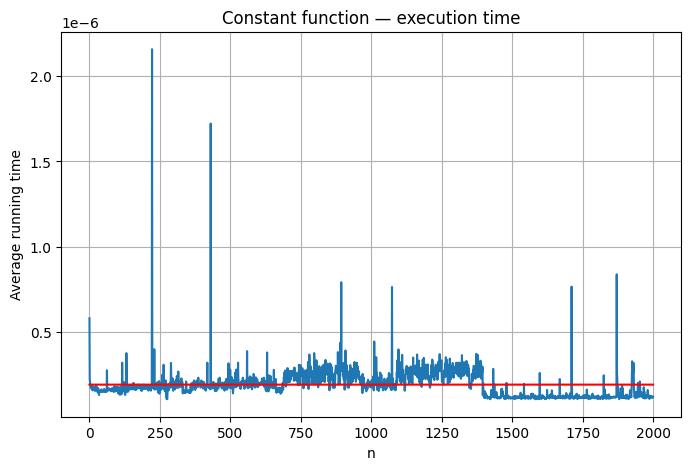

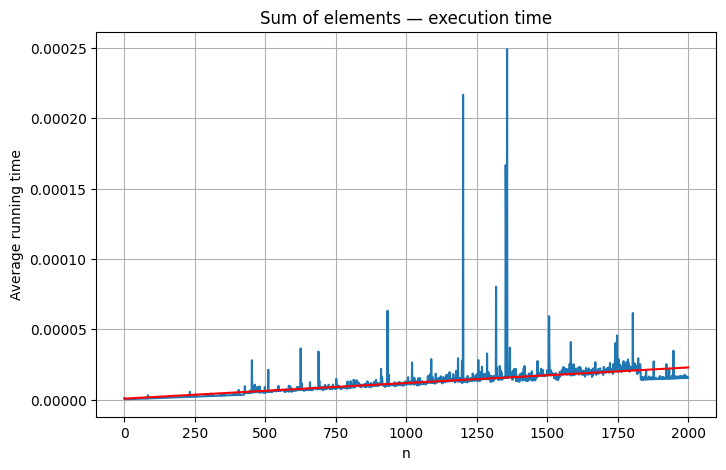

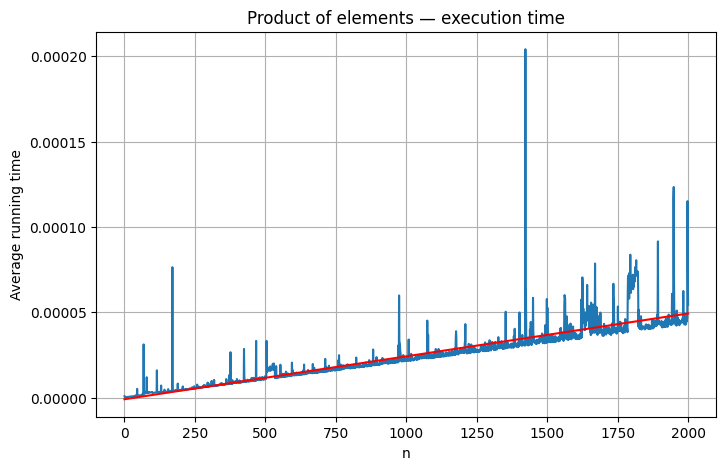

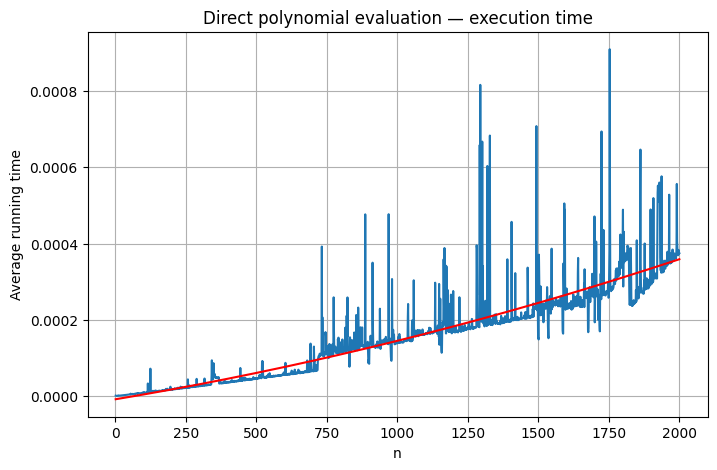

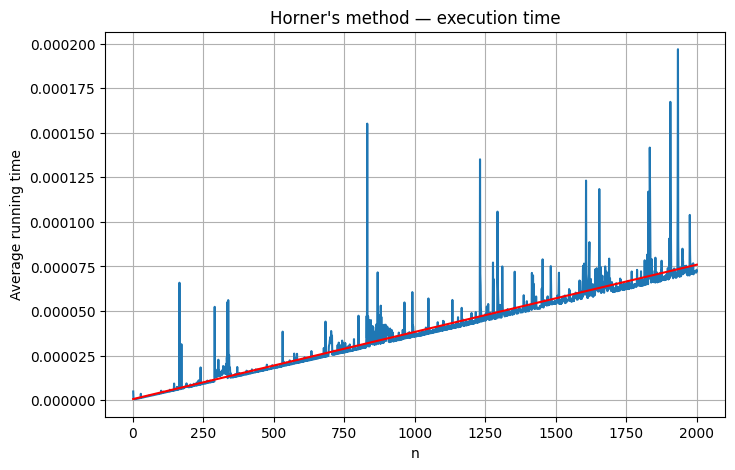

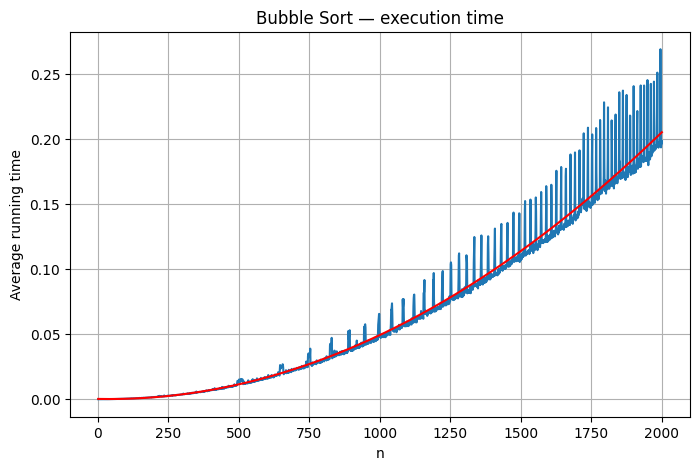

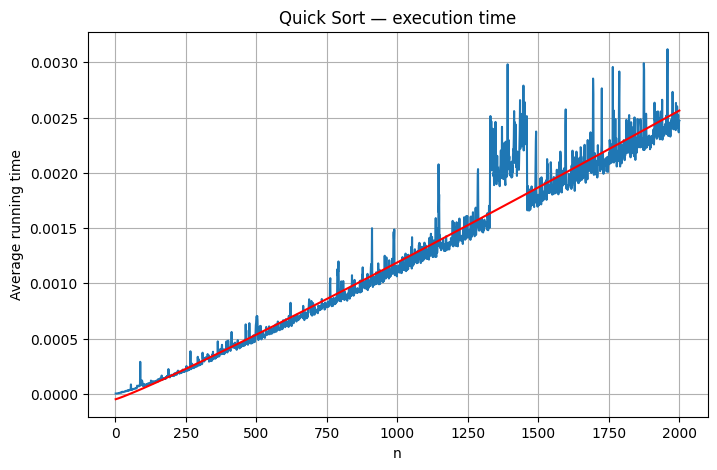

/tmp/ipykernel_14804/2598709624.py:14: RuntimeWarning: invalid value encountered in log
  return a * n * np.log(b * n) + c


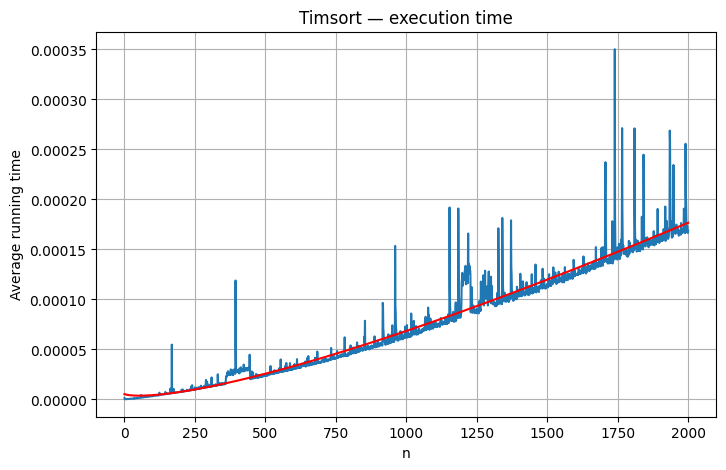

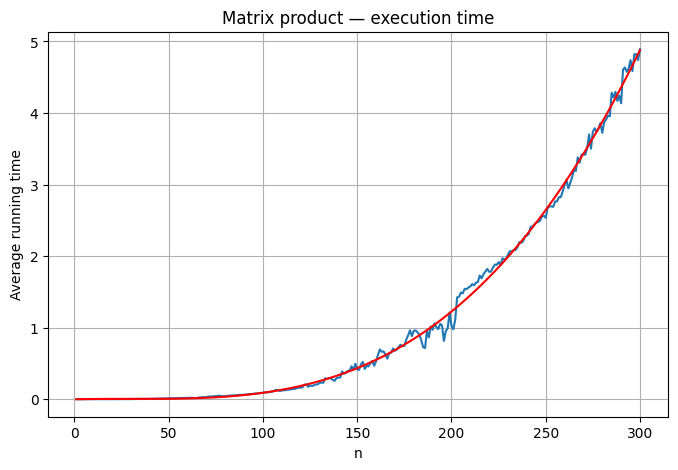

In [19]:
algorithms_vector = [
    ("Constant function", const_function, const_fun, None),
    ("Sum of elements", sum_function, line_fun, None),
    ("Product of elements", product_function, line_fun, None),
    ("Direct polynomial evaluation", polynom_function, quadr_fun, None),
    ("Horner's method", horners_function, line_fun, None),
    ("Bubble Sort", bubble_function, quadr_fun, None),
    ("Quick Sort", quicksort_function,nlog_fun, [1e-8, 1, 0]),
    ("Timsort", timsort,nlog_fun, [1e-8, 1, 0]),
]

for name, func, fit_fun, p0 in algorithms_vector:
    times = run_f(func, n_vector)
    generate_plot(n_vector, times, f"{name} — execution time", fit_fun, p0)

matrix_times = run_f(matrix_product, n_matrix, matrix=True)
generate_plot(n_matrix, matrix_times, "Matrix product — execution time", cube_fun)

Data Structures and Methods  
1. Constant, Sum, product functions - using one-dimensional array (list). In product function also used accumulator variable (prod), which is saving calculating's result on each loop iteration.
2. Direct polynomial evaluation - using array and accumulator variable either. Each loop iteration the product of the coefficient and x raised to the power is added to the result.  
3. Horner's method - the array is processed in reverse order. Each iteration result variable is updated with the value of the result multiplied by x, plus the coefficient.
4. Bubble Sort of the elements of 𝒗 - two nested loops used. Each array element compares with right neighbour and swaps if it bigger.
5. Quick Sort of the elements of 𝒗 - array is recursively divivded for two parts (and in the half is one value - pivot). Algorithm is searching smaller values than pivot on the right side, and bigger values on the left, and swaps it
6. Timsort of the elements of 𝒗 - Python's built-in sorted() function was used, which internally uses the Timsort algorithm (a hybrid of Insertion Sort and Merge Sort, adaptive to already-sorted portions of the data)
7. Matrix product - three nested loops, brute-force for each matrix element.

## Conclusion
The empirical results generally align with the theoretical ones. The shape of the actual plots matches the plots of the approximation functions.  
There are some outliers that do not affect trends (these are likely linked to technical reasons, not the exact execution time).  
Matrix product showed the best agreement between empirical and theoretical lines. The "noisiest" one(with the most outliers) is Direct polynomial evaluation.